In [7]:
import polars as pl
import numpy as np
import glob
from datetime import datetime

In [8]:
dir_name = "data/processed/binance/spot/BTC-USDT"

orderbook_path = f"{dir_name}/orderbook/20260501.parquet"
trades_path = f"{dir_name}/trades/20260501.parquet"
kline_1m_path = f"data/kline/binance/spot/BTC-USDT/1m/20260501.parquet"
kline_1h_path = f"data/kline/binance/spot/BTC-USDT/1h/20260501.parquet"

orderbook_path = sorted(glob.glob(orderbook_path))[-1]
trades_path = sorted(glob.glob(trades_path))[-1]
kline_path = sorted(glob.glob(kline_1m_path))[-1]
htf_path = sorted(glob.glob(kline_1h_path))[-1]

ob_df = pl.scan_parquet(orderbook_path).select(['timestamp','micro_price','imbalance','spread','mid_price','bid_prices','bid_volumes','ask_prices','ask_volumes']).sort('timestamp')
td_df = pl.scan_parquet(trades_path).with_columns([
    pl.when(pl.col('side') == 'buy').then(1).when(pl.col('side') == 'sell').then(-1).otherwise(0).alias('side')
]).sort('timestamp').select(['timestamp','price','amount','turnover','side'])
kl_df = pl.scan_parquet(kline_path).sort('open_time')
htf_df = pl.scan_parquet(htf_path).sort('open_time')

full_df = ob_df.join_asof(td_df,on='timestamp',strategy="backward")
final_df = full_df.join_asof(kl_df.rename({'open_time':'timestamp'}),on='timestamp',strategy="backward")
final_df = final_df.with_columns([
    pl.from_epoch('timestamp',time_unit='ms').alias('date'),
    pl.col('price').forward_fill(),
    # pl.col('side').forward_fill(),
    pl.col('amount').fill_null(0),
    pl.col('turnover').fill_null(0)
]).sort('date')
df = final_df.collect()

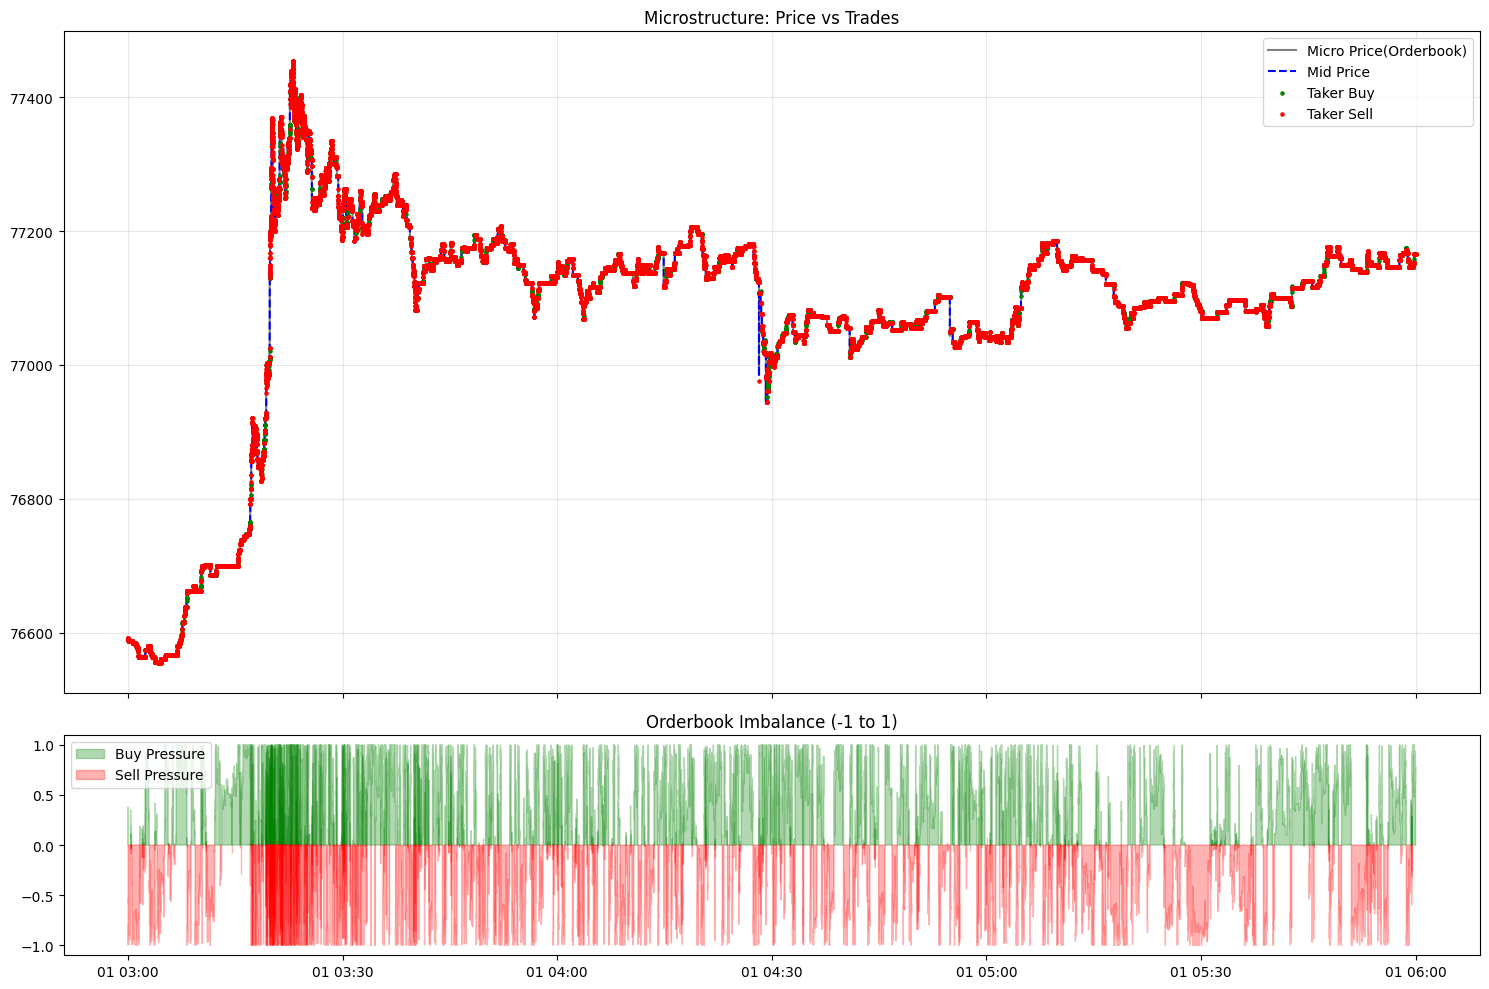

In [9]:
import matplotlib.pyplot as plt

df_plt = df.with_columns([
    pl.when(pl.col('side') == 1).then(pl.col('price')).otherwise(None).alias('trade_buy'),
    pl.when(pl.col('side') == -1).then(pl.col('price')).otherwise(None).alias('trade_sell')
]).filter((pl.col('date') > datetime(2026,5,1,3)) & (pl.col('date') < datetime(2026,5,1,6)))
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(15,10),sharex=True,gridspec_kw={'height_ratios':[3,1]})
ax1.plot(df_plt['date'],df_plt['micro_price'],label='Micro Price(Orderbook)',color='black',alpha=0.5)
ax1.plot(df_plt['date'],df_plt['mid_price'],label='Mid Price',color='blue',linestyle='--')

ax1.scatter(df_plt['date'],df_plt['trade_buy'],label='Taker Buy',color='green',s=5,zorder=5)
ax1.scatter(df_plt['date'],df_plt['trade_sell'],label='Taker Sell',color='red',s=5,zorder=5)

ax1.set_title('Microstructure: Price vs Trades')
ax1.legend()
ax1.grid(True,alpha=0.3)

ax2.fill_between(df_plt['date'],df_plt['imbalance'],0,where=(df_plt['imbalance'] >= 0),color='green',alpha=0.3,label='Buy Pressure')
ax2.fill_between(df_plt['date'],df_plt['imbalance'],0,where=(df_plt['imbalance'] < 0),color='red',alpha=0.3,label='Sell Pressure')
ax2.set_ylim(-1.1,1.1)
ax2.set_title('Orderbook Imbalance (-1 to 1)')
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
def calc_vamp_expr(depth=10) -> pl.Expr:
    vamp_bid = (pl.col('bid_prices').list.slice(0,depth) * pl.col('bid_volumes').list.slice(0,depth)).list.sum() / pl.col('bid_volumes').list.slice(0,depth).list.sum()
    vamp_ask = (pl.col('ask_prices').list.slice(0,depth) * pl.col('ask_volumes').list.slice(0,depth)).list.sum() / pl.col('ask_volumes').list.slice(0,depth).list.sum()
    return ((vamp_bid + vamp_ask) / 2).alias('vamp')

def calc_ofi_expr(window_size:str='5000ms') -> pl.Expr:
    p_b = pl.col('bid_prices').list.get(0)
    v_b = pl.col('bid_volumes').list.get(0)
    p_a = pl.col('ask_prices').list.get(0)
    v_a = pl.col('ask_volumes').list.get(0)

    db = (pl.when(p_b > p_b.shift(1).fill_null(0)).then(v_b).when(p_b == p_b.shift(1).fill_null(0)).then(v_b - v_b.shift(1)).otherwise(-v_b.shift(1)))
    da = (pl.when(p_a < p_a.shift(1).fill_null(0)).then(v_a).when(p_a == p_a.shift(1).fill_null(0)).then(v_a - v_a.shift(1)).otherwise(-v_a.shift(1)))

    return (db - da).rolling_mean_by(by='date',window_size=window_size,min_samples=1).alias('ofi')

def calc_depth_centroid_expr(side='ask',depth=20) -> pl.Expr:
    prices = pl.col(f'{side}_prices').list.slice(0,depth)
    best_price = pl.col(f'{side}_prices').list.get(0)
    volumes = pl.col(f'{side}_volumes').list.slice(0,depth)

    dist = (prices - best_price).list.eval(pl.element().abs())

    weighted_dist = (dist * volumes).list.sum() / volumes.list.sum()
    return weighted_dist.alias(f'{side}_centroid')


df = df.with_columns([
    pl.col('side').forward_fill()
])
df = df.fill_null(0)

df = df.with_columns([
    pl.col('imbalance').rolling_mean_by(by='date',window_size='5000ms',min_samples=1).alias('imbalance_smooth'),
    pl.col('imbalance').diff().fill_null(0).alias('imbalance_delta'),
    (pl.col('imbalance') > 0.8).rolling_sum_by(by='date',window_size='5000ms',min_samples=1).alias('buy_intensity_duration'),
    (pl.col('imbalance') - pl.col('imbalance').rolling_mean_by(by='date',window_size='5000ms',min_samples=1)).alias('imbalance_bias'),
    (pl.col('imbalance') / pl.col('spread')).alias('imb_sp')
])

df = df.with_columns([
    calc_vamp_expr(),
    calc_ofi_expr()
]).fill_null(0)

df = df.with_columns([
    ((pl.col('micro_price') - pl.col('micro_price').shift(10)) / pl.col('micro_price').shift(10)).alias('price_slope_5s'),
    pl.col('ofi').diff().fill_null(0).alias('ofi_momentum'),
    (pl.col('imbalance') / (pl.col('micro_price').rolling_std_by(by='date',window_size='5000ms',min_samples=1) + 1e-8)).alias('vol_adj_imb')
])

df = df.with_columns([
    (pl.col('ask_volumes').list.slice(0,5).list.sum().diff().fill_null(0)).alias('ask_depth_delta_5'),
    (pl.col('bid_volumes').list.slice(0,5).list.sum().diff().fill_null(0)).alias('bid_depth_delta_5'),
    ((pl.col('ask_prices').list.get(4) - pl.col('ask_prices').list.get(0)) / pl.col('ask_volumes').list.slice(0,5).list.sum() * 10000).alias('ask_slope_5')
])

df = df.with_columns([
    calc_depth_centroid_expr('bid'),
    calc_depth_centroid_expr('ask')
]).with_columns([
    (pl.col('bid_centroid') - pl.col('ask_centroid')).alias('centroid_spread'),
    (pl.col('bid_volumes').list.slice(0,5).list.sum() / pl.col('bid_volumes').list.slice(0,20).list.sum()).alias('bid_concentration'),
    (pl.col('ask_volumes').list.slice(0,5).list.sum() / pl.col('ask_volumes').list.slice(0,20).list.sum()).alias('ask_concentration'),
    ((pl.col('ask_prices').list.get(9) - pl.col('ask_prices').list.get(0)) / pl.col('ask_volumes').list.slice(0,10).list.sum() * 10000).alias('ask_slope_10')
])

df.head(-10)

timestamp,micro_price,imbalance,spread,mid_price,bid_prices,bid_volumes,ask_prices,ask_volumes,price,amount,turnover,side,open,height,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base,taker_buy_quote,date,imbalance_smooth,imbalance_delta,buy_intensity_duration,imbalance_bias,imb_sp,vamp,ofi,price_slope_5s,ofi_momentum,vol_adj_imb,ask_depth_delta_5,bid_depth_delta_5,ask_slope_5,bid_centroid,ask_centroid,centroid_spread,bid_concentration,ask_concentration,ask_slope_10
i64,f64,f64,f64,f64,list[f64],list[f64],list[f64],list[f64],f64,f64,f64,i32,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,datetime[μs],f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1777593600014,76346.578854,0.770727,0.01,76346.575,"[76346.57, 76346.56, … 76343.81]","[3.88826, 0.00014, … 0.00014]","[76346.58, 76346.59, … 76349.51]","[0.50345, 0.00014, … 0.00007]",0.0,0.0,0.0,0,76346.58,76396.19,76320.42,76381.58,112.20956,1777593659999,8.5692e6,3567,99.33187,7.5858e6,2026-05-01 00:00:00.014,0.770727,0.0,0,0.0,77.072712,76346.618554,0.0,null,0.0,null,0.0,0.0,14287.982219,0.174696,0.330382,-0.155686,0.817281,0.738398,17532.05078
1777593600114,76346.578483,0.696506,0.01,76346.575,"[76346.57, 76346.56, … 76342.27]","[4.07197, 0.00014, … 0.00655]","[76346.58, 76346.59, … 76349.51]","[0.72845, 0.00014, … 0.00007]",0.0,0.0,0.0,0,76346.58,76396.19,76320.42,76381.58,112.20956,1777593659999,8.5692e6,3567,99.33187,7.5858e6,2026-05-01 00:00:00.114,0.733616,-0.074221,0,-0.037111,69.650572,76346.555573,-0.04129,null,-0.04129,2654.141088,0.225,0.45032,9877.627174,0.176736,0.214017,-0.03728,0.857784,0.841087,13608.417778
1777593600214,76346.5785,0.699953,0.01,76346.575,"[76346.57, 76346.56, … 76342.27]","[4.12713, 0.00014, … 0.00655]","[76346.58, 76346.59, … 76350.0]","[0.72845, 0.00014, … 0.00634]",0.0,0.0,0.0,0,76346.58,76396.19,76320.42,76381.58,112.20956,1777593659999,8.5692e6,3567,99.33187,7.5858e6,2026-05-01 00:00:00.214,0.722395,0.003448,0,-0.022442,69.995346,76346.505683,0.006935,null,0.048225,3341.548934,0.0,0.05516,9877.627174,0.174832,0.178779,-0.003947,0.859321,0.909683,19254.237288
1777593600314,76346.578501,0.700259,0.01,76346.575,"[76346.57, 76346.56, … 76342.27]","[4.13247, 0.00014, … 0.00655]","[76346.58, 76346.59, … 76349.45]","[0.72852, 0.00014, … 0.00014]",0.0,0.0,0.0,0,76346.58,76396.19,76320.42,76381.58,112.20956,1777593659999,8.5692e6,3567,99.33187,7.5858e6,2026-05-01 00:00:00.314,0.716861,0.000305,0,-0.016603,70.025859,76346.505668,0.00638,null,-0.000555,3895.42219,0.00007,0.00534,9876.678692,0.17465,0.326165,-0.151515,0.859467,0.844471,19256.064982
1777593600414,76346.578502,0.700316,0.01,76346.575,"[76346.57, 76346.56, … 76342.86]","[4.13233, 0.00014, … 0.00719]","[76346.58, 76346.59, … 76349.45]","[0.72833, 0.00014, … 0.00014]",76346.58,0.00006,4.580795,1,76346.58,76396.19,76320.42,76381.58,112.20956,1777593659999,8.5692e6,3567,99.33187,7.5858e6,2026-05-01 00:00:00.414,0.713552,0.000058,0,-0.013236,70.031642,76346.505753,0.004797,null,-0.001583,4376.49804,-0.00019,-0.00014,9879.253568,0.177744,0.06509,0.112655,0.857334,0.955528,19801.711627
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1777679998514,78231.128518,0.703578,0.01,78231.125,"[78231.12, 78231.11, … 78229.53]","[3.37926, 0.00522, … 0.00103]","[78231.13, 78231.14, … 78236.08]","[0.58799, 0.00035, … 0.00014]",78231.13,0.00023,17.99316,1,78192.68,78249.6,78192.68,78231.13,11.79363,1777679999999,922486.980145,1167,9.16598,716963.40922,2026-05-01 23:59:58.514,0.056658,0.000046,3,0.64692,70.357804,78231.24142,0.085198,-6.3230e-9,0.000006,324.453355,-0.00007,0.00035,33968.583047,0.014601,1.049597,-1.034995,0.941453,0.769783,45297.014653
1777679998614,78231.128518,0.703608,0.01,78231.125,"[78231.12, 78231.11, … 78229.53]","[3.37926, 0.00522, … 0.00103]","[78231.13, 78231.14, … 78235.68]","[0.58792, 0.00035, … 0.00007]",78231.13,0.00023,17.99316,1,78192.68,78249.6,78192.68,78231.13,11.79363,1777679999999,922486.980145,1167,

In [ ]:
from lightgbm import LGBMRegressor,early_stopping
from scipy.stats import pearsonr

train_df = df.with_columns([
    ((pl.col("vamp").reverse().rolling_max(window_size=20).reverse().shift(-20) 
      - pl.col("micro_price")) / pl.col("micro_price") * 10000).alias("label")
]).drop_nulls().drop_nans()

n = len(train_df)
split_idx = int(n * 0.7)

X = train_df.select(['imbalance','spread','imbalance_smooth','buy_intensity_duration','imbalance_delta','imbalance_bias','ofi','imb_sp','price_slope_5s','ofi_momentum','vol_adj_imb','ask_depth_delta_5','bid_depth_delta_5','ask_slope_5','bid_centroid','ask_centroid','centroid_spread','bid_concentration','ask_concentration','ask_slope_10']).to_pandas()
X = X.shift(1)
y = train_df.select(['label']).to_pandas().values.ravel()

X_train,X_valid = X.iloc[:split_idx],X.iloc[split_idx:]
y_train,y_valid = y[:split_idx],y[split_idx:]

model_lgb = LGBMRegressor(
    objective='regression_l1',
    n_estimators=1500,
    max_depth=7,
    num_leaves=63,
    learning_rate=0.05,
    min_child_samples=20,
    min_split_gain=0.0,
    min_child_weight=0.001,
    reg_alpha=0.5,
    reg_lambda=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    importance_type="gain"
)

model_lgb.fit(X_train,y_train,eval_set=[(X_valid,y_valid)],callbacks=[early_stopping(50)])
preds_lgb = model_lgb.predict(X_valid)
print(pl.DataFrame(preds_lgb).describe())
ic,p_values = pearsonr(preds_lgb,y_valid)
print(f"ic: {ic},P-value: {p_values}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[44]	valid_0's l1: 0.252881
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ column_0  │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 259054.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 0.023689  │
│ std        ┆ 0.102316  │
│ min        ┆ -0.431598 │
│ 25%        ┆ -0.000635 │
│ 50%        ┆ 0.000987  │
│ 75%        ┆ 0.006811  │
│ max        ┆ 0.974544  │
└────────────┴───────────┘
ic: 0.27607689663215773,P-value: 0.0


In [12]:
valid_df = train_df.tail(len(preds_lgb)).with_columns([
    pl.Series(name='pred',values=preds_lgb)
])

threshold = 1.5
strong_signals = valid_df.filter(pl.col('pred') > threshold)
print(f"高於 {threshold} BPS 嘅訊號數量: {strong_signals.height}")
if strong_signals.height > 0:
    print(strong_signals.select(['date', 'pred', 'label', 'micro_price']))
    win_rate = strong_signals.filter(pl.col('label') > 0).height / valid_df.height
    avg_return = strong_signals.select(pl.col('label').mean()).item()
    print(f"🎯 狙擊勝率: {win_rate*100:.2f}%")
    print(f"💰 平均真實回報 (扣費前): {avg_return:.4f} BPS")

    net_return = avg_return - 0.8
    print(f"⛽ 扣費後預期每筆利潤: {net_return:.4f} BPS")
else:
    print("冇任何訊號高過門檻，狙擊手繼續埋伏...")

高於 1.5 BPS 嘅訊號數量: 0
冇任何訊號高過門檻，狙擊手繼續埋伏...
